# ExpressionPerformer Gene Embedding Export + Benchmark Prep

This notebook exports static learned gene embeddings from a trained ExpressionPerformer checkpoint and prepares files compatible with gene-embedding-benchmarks.

Workflow:
1. Load checkpoint and reconstruct architecture from saved config
2. Extract `model.gene_embedding.weight`
3. Attach gene symbols using `canonical_genes.csv` order
4. Map symbols to Entrez IDs with `mygene`
5. Export benchmark-ready files
6. Run nearest-neighbor sanity checks

In [1]:
# Optional install cell (run if needed)
# %pip install mygene umap-learn

In [2]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

try:
    import umap
    HAS_UMAP = True
except Exception:
    HAS_UMAP = False

import mygene

plt.rcParams['figure.dpi'] = 120
torch.set_grad_enabled(False)

/home/walt/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-05-26 21:28:15.710734: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-26 21:28:15.805583: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-05-26 21:28:15.833009: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-26 21:28:16.248461: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimi

AttributeError: _ARRAY_API not found

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/walt/miniconda3/envs/esm2/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/walt/miniconda3/envs/esm2/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/walt/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/walt/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
 

AttributeError: _ARRAY_API not found

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "/home/walt/miniconda3/envs/esm2/lib/python3.10/runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/home/walt/miniconda3/envs/esm2/lib/python3.10/runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "/home/walt/.local/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/home/walt/.local/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
    app.start()
 

AttributeError: _ARRAY_API not found

torch.autograd.grad_mode.set_grad_enabled(mode=False)

In [3]:
# Paths (adjust if your layout changes)
CHECKPOINT_PATH = Path('../Attention/checkpoints_performer/r7hnr92k/best_model.pt')
CANONICAL_GENES_PATH = Path('canonical_genes.csv')
BENCHMARK_ALL_GENES_DIR = Path('gene-embedding-benchmarks/data/embeddings/all_genes')

assert CHECKPOINT_PATH.exists(), f'Checkpoint not found: {CHECKPOINT_PATH.resolve()}'
assert CANONICAL_GENES_PATH.exists(), f'Canonical genes file not found: {CANONICAL_GENES_PATH.resolve()}'
BENCHMARK_ALL_GENES_DIR.mkdir(parents=True, exist_ok=True)

print('Checkpoint:', CHECKPOINT_PATH.resolve())
print('Canonical genes:', CANONICAL_GENES_PATH.resolve())
print('Output directory:', BENCHMARK_ALL_GENES_DIR.resolve())

Checkpoint: /home/walt/Attention/checkpoints_performer/r7hnr92k/best_model.pt
Canonical genes: /home/walt/tcga/canonical_genes.csv
Output directory: /home/walt/tcga/gene-embedding-benchmarks/data/embeddings/all_genes


## Model reconstruction helpers

These classes match the training architecture used in `train_flash.py` for loading state dicts exactly.

In [4]:
class RotaryExpressionEmbedding(nn.Module):
    def __init__(self, dim: int, base: float = 100.0, mask_token_id: float = -10):
        super().__init__()
        self.dim = int(dim)
        self.mask_token_id = mask_token_id
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer('inv_freq', inv_freq)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x_mask_idx = (x == self.mask_token_id).nonzero(as_tuple=False)
        freqs = torch.einsum('bi,j->bij', x, self.inv_freq)
        emb = torch.cat([freqs.sin(), freqs.cos()], dim=-1)
        if len(x_mask_idx) > 0:
            emb[x_mask_idx[:, 0], x_mask_idx[:, 1], :] = 0
        return emb


class FlashTransformerLayer(nn.Module):
    def __init__(self, hidden_dim: int, ffn_dim: int, n_heads: int, dropout: float = 0.0):
        super().__init__()
        if hidden_dim % n_heads != 0:
            raise ValueError(f'hidden_dim ({hidden_dim}) must be divisible by n_heads ({n_heads})')
        self.hidden_dim = int(hidden_dim)
        self.n_heads = int(n_heads)
        self.head_dim = self.hidden_dim // self.n_heads
        self.dropout = float(dropout)

        self.q_proj = nn.Linear(self.hidden_dim, self.hidden_dim)
        self.k_proj = nn.Linear(self.hidden_dim, self.hidden_dim)
        self.v_proj = nn.Linear(self.hidden_dim, self.hidden_dim)
        self.out_proj = nn.Linear(self.hidden_dim, self.hidden_dim)

        self.norm1 = nn.LayerNorm(self.hidden_dim)
        self.norm2 = nn.LayerNorm(self.hidden_dim)

        self.ffn = nn.Sequential(
            nn.Linear(self.hidden_dim, int(ffn_dim)),
            nn.GELU(),
            nn.Linear(int(ffn_dim), self.hidden_dim),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = self.norm1(x)
        bsz, genes, _ = h.shape

        q = self.q_proj(h).view(bsz, genes, self.n_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(h).view(bsz, genes, self.n_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(h).view(bsz, genes, self.n_heads, self.head_dim).transpose(1, 2)

        attn = F.scaled_dot_product_attention(
            q, k, v, attn_mask=None, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        attn = attn.transpose(1, 2).contiguous().view(bsz, genes, self.hidden_dim)
        x = x + self.out_proj(attn)
        x = x + self.ffn(self.norm2(x))
        return x


class ExpressionPerformer(nn.Module):
    def __init__(
        self,
        num_genes: int,
        hidden_dim: int = 256,
        n_heads: int = 8,
        n_layers: int = 4,
        ffn_dim: int = 1024,
        ree_base: float = 100.0,
        mask_token_id: float = -10,
        feature_type: str = 'sqr',
        compute_type: str = 'iter',
        include_species_embedding: bool = False,
        num_species: int = 1,
    ):
        super().__init__()
        self.num_genes = int(num_genes)
        self._hidden_dim = int(hidden_dim)
        self.include_species_embedding = bool(include_species_embedding)

        self.gene_embedding = nn.Embedding(num_genes, hidden_dim)
        self.ree = RotaryExpressionEmbedding(hidden_dim, base=ree_base, mask_token_id=mask_token_id)

        if self.include_species_embedding:
            self.species_embedding = nn.Embedding(int(num_species), hidden_dim)

        self.feature_type = str(feature_type).strip().lower()
        self.use_flash = self.feature_type == 'flash'

        if self.use_flash:
            self.layers = nn.ModuleList([
                FlashTransformerLayer(hidden_dim, ffn_dim, n_heads, dropout=0.0)
                for _ in range(n_layers)
            ])
        else:
            try:
                from slim_performer_model import SLiMPerformerLayer
            except Exception as exc:
                raise ImportError(
                    'Non-flash checkpoints require slim_performer_model.py available on PYTHONPATH.'
                ) from exc

            self.layers = nn.ModuleList([
                SLiMPerformerLayer(hidden_dim, ffn_dim, n_heads, feature_type, compute_type, on_gptln=True)
                for _ in range(n_layers)
            ])

        self.output_map = nn.Linear(hidden_dim, 1)


def strip_module_prefix(state_dict: Dict[str, torch.Tensor]) -> Dict[str, torch.Tensor]:
    if all(key.startswith('module.') for key in state_dict.keys()):
        return {key[len('module.'):]: value for key, value in state_dict.items()}
    return state_dict


def infer_num_layers_from_state_dict(state_dict: Dict[str, torch.Tensor]) -> int:
    layer_idxs = set()
    for key in state_dict:
        if key.startswith('layers.'):
            parts = key.split('.')
            if len(parts) > 1 and parts[1].isdigit():
                layer_idxs.add(int(parts[1]))
    if not layer_idxs:
        raise ValueError('Could not infer number of transformer layers from state_dict.')
    return max(layer_idxs) + 1


def load_expressionperformer_from_checkpoint(checkpoint_path: Path) -> Tuple[nn.Module, dict]:
    payload = torch.load(checkpoint_path, map_location='cpu')
    state = payload.get('model_state_dict', payload)
    state = strip_module_prefix(state)
    cfg = dict(payload.get('config', {}))

    gene_weight = state['gene_embedding.weight']
    num_genes, hidden_dim = int(gene_weight.shape[0]), int(gene_weight.shape[1])

    n_layers = int(cfg.get('num_layers', infer_num_layers_from_state_dict(state)))
    n_heads = int(cfg.get('num_heads', 8))
    ffn_dim = int(cfg.get('ffn_dim', 4 * hidden_dim))
    ree_base = float(cfg.get('ree_base', 100.0))
    feature_type = str(cfg.get('feature_type', 'flash')).lower()
    compute_type = str(cfg.get('compute_type', 'iter')).lower()
    include_species_embedding = bool(cfg.get('include_species_embedding', False))

    model = ExpressionPerformer(
        num_genes=num_genes,
        hidden_dim=hidden_dim,
        n_heads=n_heads,
        n_layers=n_layers,
        ffn_dim=ffn_dim,
        ree_base=ree_base,
        mask_token_id=float(cfg.get('mask_token', -10)),
        feature_type=feature_type,
        compute_type=compute_type,
        include_species_embedding=include_species_embedding,
        num_species=int(cfg.get('num_species', 1)),
    )

    missing, unexpected = model.load_state_dict(state, strict=False)
    if missing or unexpected:
        raise RuntimeError(
            f'State dict mismatch. Missing keys: {missing[:5]}, Unexpected keys: {unexpected[:5]}'
        )

    model.eval()
    return model, payload

In [5]:
model, checkpoint_payload = load_expressionperformer_from_checkpoint(CHECKPOINT_PATH)
embedding_matrix = model.gene_embedding.weight.detach().cpu().numpy()

print('Embedding matrix shape:', embedding_matrix.shape)
print('Mean:', float(embedding_matrix.mean()))
print('Std :', float(embedding_matrix.std()))
print('Checkpoint epoch:', checkpoint_payload.get('epoch'))
print('Val loss:', checkpoint_payload.get('val_loss'))

Embedding matrix shape: (15165, 512)
Mean: -0.0006098461453802884
Std : 0.9980518817901611
Checkpoint epoch: 20
Val loss: 0.14989914000034332


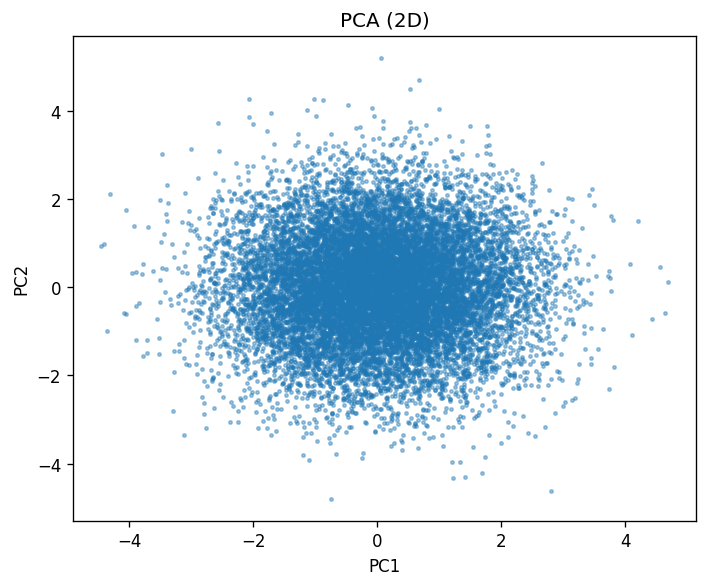

UMAP not installed. Run: %pip install umap-learn


In [6]:
# Quick PCA and UMAP views of gene embedding space
pca_2d = PCA(n_components=2, random_state=42).fit_transform(embedding_matrix)

fig, axes = plt.subplots(1, 2 if HAS_UMAP else 1, figsize=(12 if HAS_UMAP else 6, 5))
if not isinstance(axes, np.ndarray):
    axes = np.array([axes])

axes[0].scatter(pca_2d[:, 0], pca_2d[:, 1], s=4, alpha=0.4)
axes[0].set_title('PCA (2D)')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

if HAS_UMAP:
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, metric='cosine', random_state=42)
    umap_2d = reducer.fit_transform(embedding_matrix)
    axes[1].scatter(umap_2d[:, 0], umap_2d[:, 1], s=4, alpha=0.4)
    axes[1].set_title('UMAP (2D)')
    axes[1].set_xlabel('UMAP1')
    axes[1].set_ylabel('UMAP2')

plt.tight_layout()
plt.show()

if not HAS_UMAP:
    print('UMAP not installed. Run: %pip install umap-learn')

## Attach gene symbols from canonical order

`canonical_genes.csv` defines the training order. We map row i of the embedding matrix to row i in this file.

In [7]:
def build_symbol_embedding_df(embedding_matrix: np.ndarray, canonical_genes_path: Path) -> pd.DataFrame:
    genes = pd.read_csv(canonical_genes_path)
    if 'gene_symbol' not in genes.columns:
        raise ValueError('canonical_genes.csv must contain a gene_symbol column.')

    if len(genes) != embedding_matrix.shape[0]:
        raise ValueError(
            f'Row mismatch: canonical genes has {len(genes)} rows, embeddings have {embedding_matrix.shape[0]} rows.'
        )

    dim_cols = [f'dim_{i}' for i in range(embedding_matrix.shape[1])]
    emb_df = pd.DataFrame(embedding_matrix, columns=dim_cols)
    emb_df.insert(0, 'gene_symbol', genes['gene_symbol'].astype(str).values)
    return emb_df


symbol_embedding_df = build_symbol_embedding_df(embedding_matrix, CANONICAL_GENES_PATH)
print(symbol_embedding_df.shape)
symbol_embedding_df.head()

(15165, 513)


,gene_symbol,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
0,A1CF,-0.602066,0.786564,-0.687886,-0.126599,1.183547,-0.447339,-0.557441,-0.251671,0.207638,...,2.151301,0.195987,0.416481,-0.815043,0.300568,1.192004,-1.335522,-0.344417,-0.680746,0.004122
1,A2M,-0.410135,0.965243,0.928394,-0.236611,0.479311,-1.373260,-0.982485,0.722861,1.108619,...,-0.427714,1.059953,1.469716,-0.302164,-2.203065,1.097640,-0.676033,0.753971,0.111739,2.315508
2,A3GALT2,-0.635087,-0.066669,-0.945027,-0.495139,0.639256,2.902952,-0.187014,1.886925,-0.881068,...,-0.974643,-0.632867,0.601883,0.540717,0.517871,-3.043718,1.136878,-1.597365,0.670900,0.996418
3,A4GALT,0.594207,0.309217,0.417399,0.393926,0.085672,0.491490,0.236121,0.490475,1.754480,...,-0.268975,0.062739,0.592383,-0.616808,0.238764,0.249581,0.316642,1.713569,-2.355596,0.996740
4,A4GNT,0.424494,1.730273,-0.332560,1.189674,-1.332250,-1.379791,-1.572891,-0.138610,-0.814788,...,1.768673,1.496236,-0.908437,0.835704,0.302658,1.075178,-0.028045,1.572652,0.048135,1.008443


## Map symbols to Entrez IDs with mygene

The benchmark uses Entrez identifiers, so we map symbols, drop unmapped genes, and average duplicate Entrez rows.

In [8]:
def map_symbols_to_entrez(symbol_df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    mg = mygene.MyGeneInfo()
    symbols = symbol_df['gene_symbol'].tolist()

    mapping = mg.querymany(
        symbols,
        scopes='symbol',
        fields='entrezgene,symbol',
        species='human',
        as_dataframe=True,
        verbose=False,
    )

    mapping = mapping.reset_index().rename(columns={'query': 'gene_symbol'})
    if 'entrezgene' not in mapping.columns:
        mapping['entrezgene'] = np.nan

    map_df = mapping[['gene_symbol', 'entrezgene']].copy()
    map_df['gene_symbol'] = map_df['gene_symbol'].astype(str)

    merged = symbol_df.merge(map_df, on='gene_symbol', how='left')

    dim_cols = [c for c in merged.columns if c.startswith('dim_')]
    mapped = merged.dropna(subset=['entrezgene']).copy()
    mapped['entrezgene'] = mapped['entrezgene'].astype(int)

    aggregated = mapped.groupby('entrezgene', as_index=False)[dim_cols].mean()

    total_symbols = len(symbol_df)
    mapped_rows = len(mapped)
    unique_entrez = aggregated['entrezgene'].nunique()
    unmapped = total_symbols - mapped_rows
    duplicate_rows_collapsed = mapped_rows - unique_entrez

    print('Mapping stats:')
    print(f'  Total input symbols: {total_symbols}')
    print(f'  Rows mapped to Entrez: {mapped_rows}')
    print(f'  Unmapped symbols: {unmapped}')
    print(f'  Unique Entrez IDs: {unique_entrez}')
    print(f'  Duplicate rows averaged: {duplicate_rows_collapsed}')

    return aggregated, merged


entrez_embedding_df, symbol_to_entrez_merged = map_symbols_to_entrez(symbol_embedding_df)
print(entrez_embedding_df.shape)
entrez_embedding_df.head()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


Mapping stats:
  Total input symbols: 15165
  Rows mapped to Entrez: 15109
  Unmapped symbols: 56
  Unique Entrez IDs: 15109
  Duplicate rows averaged: 0
(15109, 513)


,entrezgene,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
0,2,-0.410135,0.965243,0.928394,-0.236611,0.479311,-1.373260,-0.982485,0.722861,1.108619,...,-0.427714,1.059953,1.469716,-0.302164,-2.203065,1.097640,-0.676033,0.753971,0.111739,2.315508
1,13,-0.655904,-0.057532,0.103143,-0.369966,0.291972,1.027081,-0.352663,-0.190115,-0.928606,...,0.570026,0.878918,0.736735,0.554669,1.532672,0.265628,-0.596462,-0.738667,-1.302995,1.613070
2,14,1.052420,0.482996,0.598316,-0.698279,0.222125,2.855250,0.552840,0.833779,0.396831,...,-0.280193,0.578490,0.042223,-1.118254,0.784732,0.336248,-0.440788,1.752606,1.003119,0.859356
3,15,1.172580,0.646025,1.099779,1.581960,0.247169,0.714312,-1.456273,0.323511,-0.596110,...,1.360920,-1.270870,0.173232,-0.932689,1.772209,0.248233,0.744953,-1.386048,-2.489635,-1.690470
4,18,-1.193391,0.047863,-1.395490,-0.252258,0.686646,1.215317,0.470969,0.023159,0.121146,...,-0.905006,-0.682345,-0.386901,0.397343,1.414768,-0.023635,-0.943654,-0.843139,2.506597,1.753650


## Export outputs

We export two versions so you can compare fairly:

- `all_genes`: full mapped Entrez set from your model export
- `intersect_11355`: filtered to the paper reference intersect list

Both are written in script-compatible subfolder format (headerless `.csv` matrix + `.txt` gene list).

In [ ]:
def export_method_embeddings(entrez_df: pd.DataFrame, out_dir: Path, method_name: str) -> Dict[str, Path]:
    method_dir = out_dir / method_name
    method_dir.mkdir(parents=True, exist_ok=True)

    dim_cols = [c for c in entrez_df.columns if c.startswith('dim_')]
    matrix_csv = method_dir / f'{method_name}.csv'
    gene_txt = method_dir / f'{method_name}.txt'

    entrez_df[dim_cols].to_csv(matrix_csv, header=False, index=False)
    gene_txt.write_text('\n'.join(entrez_df['entrezgene'].astype(str).tolist()) + '\n')

    return {'matrix_csv': matrix_csv, 'gene_txt': gene_txt}


# Keep the original all-genes exports
BENCHMARK_ALL_GENES_DIR.mkdir(parents=True, exist_ok=True)
all_csv_path = BENCHMARK_ALL_GENES_DIR / 'expressionperformer_embeddings.csv'
all_tsv_path = BENCHMARK_ALL_GENES_DIR / 'expressionperformer_embeddings.tsv'
entrez_embedding_df.to_csv(all_csv_path, index=False)
entrez_embedding_df.to_csv(all_tsv_path, sep='\t', index=False)

# Export method folder for all genes
all_genes_paths = export_method_embeddings(
    entrez_embedding_df,
    BENCHMARK_ALL_GENES_DIR,
    method_name='ExpressionPerformer_CUSTOM',
)

# Build paper-intersect (11,355) filtered export
INTERSECT_REF_PATH = Path(
    'gene-embedding-benchmarks/data/data_splits/gene_level_benchmark/'
    'go_generalization_folds_splits/intersect_ref_genelist.txt'
)
assert INTERSECT_REF_PATH.exists(), f'Intersect reference list not found: {INTERSECT_REF_PATH.resolve()}'

intersect_ids = {
    int(x.strip()) for x in INTERSECT_REF_PATH.read_text().splitlines() if x.strip()
}
intersect_df = entrez_embedding_df[entrez_embedding_df['entrezgene'].isin(intersect_ids)].copy()

# Keep deterministic row order by Entrez ID
intersect_df = intersect_df.sort_values('entrezgene').reset_index(drop=True)

intersect_paths = export_method_embeddings(
    intersect_df,
    BENCHMARK_ALL_GENES_DIR,
    method_name='ExpressionPerformer_CUSTOM_INTERSECT11355',
)

print('All-genes CSV:', all_csv_path.resolve())
print('All-genes TSV:', all_tsv_path.resolve())
print('All-genes method folder:', all_genes_paths['matrix_csv'].parent.resolve())
print('Intersect method folder:', intersect_paths['matrix_csv'].parent.resolve())
print('All-genes unique Entrez:', entrez_embedding_df['entrezgene'].nunique())
print('Intersect ref size:', len(intersect_ids))
print('Intersect export unique Entrez:', intersect_df['entrezgene'].nunique())
print('Intersect overlap recovered:', intersect_df['entrezgene'].nunique())


csv_path: /home/walt/tcga/gene-embedding-benchmarks/data/embeddings/all_genes/expressionperformer_embeddings.csv
tsv_path: /home/walt/tcga/gene-embedding-benchmarks/data/embeddings/all_genes/expressionperformer_embeddings.tsv
matrix_csv: /home/walt/tcga/gene-embedding-benchmarks/data/embeddings/all_genes/ExpressionPerformer_CUSTOM/ExpressionPerformer_CUSTOM.csv
gene_txt: /home/walt/tcga/gene-embedding-benchmarks/data/embeddings/all_genes/ExpressionPerformer_CUSTOM/ExpressionPerformer_CUSTOM.txt


## Biological sanity check: nearest neighbors (cosine)

Checks whether known genes have biologically plausible neighborhood structure in embedding space.

In [10]:
def nearest_neighbors_by_symbol(
    symbol_df: pd.DataFrame,
    query_gene: str,
    top_k: int = 10,
) -> pd.DataFrame:
    dim_cols = [c for c in symbol_df.columns if c.startswith('dim_')]
    mat = symbol_df[dim_cols].values
    symbols = symbol_df['gene_symbol'].astype(str).values

    symbol_to_idx = {g: i for i, g in enumerate(symbols)}
    if query_gene not in symbol_to_idx:
        raise KeyError(f'{query_gene} not found in symbol embedding table.')

    idx = symbol_to_idx[query_gene]
    sims = cosine_similarity(mat[idx:idx+1], mat).ravel()

    order = np.argsort(-sims)
    order = [i for i in order if i != idx][:top_k]

    return pd.DataFrame({
        'query_gene': query_gene,
        'neighbor_gene': symbols[order],
        'cosine_similarity': sims[order],
    })


for gene in ['TP53', 'BRCA1', 'CD3D', 'MKI67']:
    print(f'\nTop neighbors for {gene}:')
    try:
        display(nearest_neighbors_by_symbol(symbol_embedding_df, gene, top_k=10))
    except KeyError as exc:
        print(str(exc))


Top neighbors for TP53:


,query_gene,neighbor_gene,cosine_similarity
0,TP53,FADS6,0.159648
1,TP53,CRBN,0.152329
2,TP53,SSU72,0.149677
3,TP53,MTNR1B,0.147815
4,TP53,SHISAL2B,0.147651
5,TP53,ZNF23,0.146585
6,TP53,BRK1,0.143637
7,TP53,NKX2-4,0.140170
8,TP53,FLII,0.137114
9,TP53,CHRM3,0.134992



Top neighbors for BRCA1:


,query_gene,neighbor_gene,cosine_similarity
0,BRCA1,RECQL4,0.162280
1,BRCA1,EPHA8,0.161063
2,BRCA1,CLDN18,0.153558
3,BRCA1,XAB2,0.150665
4,BRCA1,PTBP1,0.148606
5,BRCA1,TMEM177,0.146921
6,BRCA1,ARID3B,0.146593
7,BRCA1,LURAP1,0.144593
8,BRCA1,IL17RE,0.143400
9,BRCA1,CLSTN2,0.140999



Top neighbors for CD3D:


,query_gene,neighbor_gene,cosine_similarity
0,CD3D,KLF1,0.175486
1,CD3D,EYA3,0.170860
2,CD3D,ZNF689,0.159259
3,CD3D,TSTD2,0.154349
4,CD3D,MID1IP1,0.147986
5,CD3D,IMPA2,0.147924
6,CD3D,HAGHL,0.147028
7,CD3D,FBXW5,0.144286
8,CD3D,SIK2,0.143214
9,CD3D,MTBP,0.141801



Top neighbors for MKI67:
'MKI67 not found in symbol embedding table.'


## Run all benchmarks

Runs all gene-level (GO, GO generalization, OMIM) and gene-pair (SL, NG, TF, Pombe) benchmarks via subprocess.
Results are saved to `gene-embedding-benchmarks/results/expressionperformer/`.


In [ ]:
import concurrent.futures as cf
import os
import subprocess
import sys
import time

BENCHMARK_REPO = Path('gene-embedding-benchmarks')

# Toggle which embedding export to benchmark:
# - 'ExpressionPerformer_CUSTOM' (all genes)
# - 'ExpressionPerformer_CUSTOM_INTERSECT11355' (paper-parity intersect set)
METHOD_SUBFOLDER_NAME = 'ExpressionPerformer_CUSTOM_INTERSECT11355'
APPEND_METHOD_NAME = 'ExpressionPerformer_INTERSECT11355'

SUBFOLDER = str(BENCHMARK_ALL_GENES_DIR / METHOD_SUBFOLDER_NAME)
RESULTS_ROOT = BENCHMARK_REPO / 'results' / 'expressionperformer'
GENE_LEVEL_SCRIPT = str(BENCHMARK_REPO / 'src' / 'gene_level_benchmark' / 'gene_level_benchmarks.py')
GENE_PAIR_SCRIPT = str(BENCHMARK_REPO / 'src' / 'gene_pair_benchmark' / 'gene_pair_benchmarks.py')
SPLITS_DIR = BENCHMARK_REPO / 'data' / 'data_splits'

GO_OUT = RESULTS_ROOT / 'go'
GO_GEN_OUT = RESULTS_ROOT / 'go_generalization'
OMIM_OUT = RESULTS_ROOT / 'omim'
PAIR_OUT = RESULTS_ROOT / 'gene_pair'

for out_dir in [GO_OUT, GO_GEN_OUT, OMIM_OUT, PAIR_OUT]:
    out_dir.mkdir(parents=True, exist_ok=True)

# Controls
RUN_GENE_LEVEL = True
RUN_GENE_PAIR = True
FORCE_RERUN = False

# Speed controls (CPU): these scripts are sklearn SVM-based (no GPU path by default).
# Tune these based on your machine: fewer threads/job allows more concurrent jobs.
MAX_PARALLEL_BENCHMARKS = 4
THREADS_PER_BENCHMARK = 4
PAIR_CV_N_JOBS = 2
SHOW_LAST_LOG_LINES = 25

PAIR_OPERATIONS = ['sum', 'product', 'concat']
# PAIR_OPERATIONS = ['sum']  # quick test; use all three for full benchmark


def make_benchmark_env(threads_per_job: int, pair_cv_n_jobs: int) -> dict:
    env = os.environ.copy()
    threads = str(max(1, int(threads_per_job)))
    env['GEB_NUM_THREADS'] = threads
    env['OMP_NUM_THREADS'] = threads
    env['MKL_NUM_THREADS'] = threads
    env['OPENBLAS_NUM_THREADS'] = threads
    env['NUMEXPR_NUM_THREADS'] = threads
    env['VECLIB_MAXIMUM_THREADS'] = threads
    env['BLIS_NUM_THREADS'] = threads
    env['GEB_N_JOBS'] = str(max(1, int(pair_cv_n_jobs)))
    return env


def run_benchmark(cmd: list[str], label: str, expected_output: Path | None = None, env: dict | None = None) -> dict:
    if expected_output is not None and expected_output.exists() and not FORCE_RERUN:
        return {
            'label': label,
            'status': 'SKIP',
            'duration_s': 0.0,
            'returncode': 0,
            'stdout': f'already exists: {expected_output}',
            'stderr': '',
        }

    t0 = time.time()
    result = subprocess.run([sys.executable] + cmd, capture_output=True, text=True, env=env)
    dt = time.time() - t0
    return {
        'label': label,
        'status': 'DONE' if result.returncode == 0 else 'ERROR',
        'duration_s': dt,
        'returncode': result.returncode,
        'stdout': result.stdout or '',
        'stderr': result.stderr or '',
    }


def print_job_result(res: dict):
    print(f"[{res['status']}] {res['label']} ({res['duration_s'] / 60.0:.1f} min)")
    if res['status'] == 'ERROR':
        out_tail = '\n'.join(res['stdout'].splitlines()[-SHOW_LAST_LOG_LINES:])
        err_tail = '\n'.join(res['stderr'].splitlines()[-SHOW_LAST_LOG_LINES:])
        if out_tail:
            print('--- stdout tail ---')
            print(out_tail)
        if err_tail:
            print('--- stderr tail ---')
            print(err_tail)


def run_jobs(job_specs: list[tuple[list[str], str, Path | None]], max_workers: int, env: dict):
    if not job_specs:
        return []

    results = []
    workers = max(1, min(int(max_workers), len(job_specs)))
    print(f'\nScheduling {len(job_specs)} benchmark jobs with max_workers={workers}, threads/job={THREADS_PER_BENCHMARK}, pair_cv_n_jobs={PAIR_CV_N_JOBS}')

    with cf.ThreadPoolExecutor(max_workers=workers) as ex:
        futures = [
            ex.submit(run_benchmark, cmd, label, expected_output, env)
            for cmd, label, expected_output in job_specs
        ]
        for fut in cf.as_completed(futures):
            res = fut.result()
            results.append(res)
            print_job_result(res)

    n_err = sum(1 for r in results if r['status'] == 'ERROR')
    print(f'Completed {len(results)} jobs with {n_err} errors.')
    return results


benchmark_env = make_benchmark_env(
    threads_per_job=THREADS_PER_BENCHMARK,
    pair_cv_n_jobs=PAIR_CV_N_JOBS,
)

if RUN_GENE_LEVEL:
    go_splits = SPLITS_DIR / 'gene_level_benchmark' / 'go_folds_splits'
    go_gen_splits = SPLITS_DIR / 'gene_level_benchmark' / 'go_generalization_folds_splits'
    omim_splits = SPLITS_DIR / 'gene_level_benchmark' / 'omim_folds_splits'

    gene_level_jobs = [
        ([
            GENE_LEVEL_SCRIPT,
            '--subfolder', SUBFOLDER,
            '--cv-fold1-pkl', str(go_splits / 'go_cv_fold1_dict_all.pkl'),
            '--cv-fold2-pkl', str(go_splits / 'go_cv_fold2_dict_all.pkl'),
            '--cv-fold3-pkl', str(go_splits / 'go_cv_fold3_dict_all.pkl'),
            '--holdout-pkl', str(go_splits / 'go_holdout_dict_all.pkl'),
            '-d', str(GO_OUT),
        ], 'GO gene function (56 terms)', GO_OUT / f'{METHOD_SUBFOLDER_NAME}_holdout_results.pkl'),
        ([
            GENE_LEVEL_SCRIPT,
            '--subfolder', SUBFOLDER,
            '--cv-fold1-pkl', str(go_gen_splits / 'go_cv_fold1_dict_all.pkl'),
            '--cv-fold2-pkl', str(go_gen_splits / 'go_cv_fold2_dict_all.pkl'),
            '--cv-fold3-pkl', str(go_gen_splits / 'go_cv_fold3_dict_all.pkl'),
            '--holdout-pkl', str(go_gen_splits / 'go_holdout_dict_all.pkl'),
            '-d', str(GO_GEN_OUT),
        ], 'GO generalization (19 terms)', GO_GEN_OUT / f'{METHOD_SUBFOLDER_NAME}_holdout_results.pkl'),
        ([
            GENE_LEVEL_SCRIPT,
            '--subfolder', SUBFOLDER,
            '--cv-fold1-pkl', str(omim_splits / 'omim_cv_fold1_dict_all.pkl'),
            '--cv-fold2-pkl', str(omim_splits / 'omim_cv_fold2_dict_all.pkl'),
            '--cv-fold3-pkl', str(omim_splits / 'omim_cv_fold3_dict_all.pkl'),
            '--holdout-pkl', str(omim_splits / 'omim_holdout_dict_all.pkl'),
            '-d', str(OMIM_OUT),
        ], 'OMIM disease genes (103 terms)', OMIM_OUT / f'{METHOD_SUBFOLDER_NAME}_holdout_results.pkl'),
    ]

    run_jobs(
        gene_level_jobs,
        max_workers=MAX_PARALLEL_BENCHMARKS,
        env=benchmark_env,
    )

if RUN_GENE_PAIR:
    pair_splits = SPLITS_DIR / 'gene_pair_benchmark'
    pair_jobs = []
    for task_key, task_label, pkl_name in [
        ('sl', 'SL (synthetic lethality)', 'sl_nested_cv_splits.pkl'),
        ('ng', 'NG (negative genetic)', 'ng_nested_cv_splits.pkl'),
        ('tf', 'TF (transcription factor)', 'tf_nested_cv_splits.pkl'),
        ('pombe', 'Pombe (cross-species yeast)', 'pombe_nested_cv_splits.pkl'),
    ]:
        for op in PAIR_OPERATIONS:
            suffix = f'{task_key}_{op}_outerloop_AUC'
            out_csv = PAIR_OUT / f'{METHOD_SUBFOLDER_NAME}_{suffix}.csv'
            cmd = [
                GENE_PAIR_SCRIPT,
                '--subfolder', SUBFOLDER,
                '--cv-pkl', str(pair_splits / pkl_name),
                '--operation', op,
                '--suffix', suffix,
                '-d', str(PAIR_OUT),
            ]
            pair_jobs.append((cmd, f'{task_label} [{op}]', out_csv))

    run_jobs(
        pair_jobs,
        max_workers=MAX_PARALLEL_BENCHMARKS,
        env=benchmark_env,
    )

print('\nBenchmark outputs are stored under:')
for out_dir in [GO_OUT, GO_GEN_OUT, OMIM_OUT, PAIR_OUT]:
    print(out_dir.resolve())
print('Method subfolder:', METHOD_SUBFOLDER_NAME)
print('Append method name:', APPEND_METHOD_NAME)


Running: SL (synthetic lethality) [sum]
Processing 'ExpressionPerformer_CUSTOM' | Operation: sum
Original positives: 2124, Filtered positives: 1856
Fold 0: train=7671, outer=2090
Fold 1: train=8330, outer=1810
Fold 2: train=7686, outer=2108

Results:
   fold  best_C  inner_AUC  inner_AUPRC  inner_PR@10  inner_time  outer_AUC  outer_AUPRC  outer_PR@10  outer_time  orig_pos_pairs  filtered_pos_pairs
      0      10   0.536344     0.101250     0.066667   10.172756   0.489721     0.099590          0.0    0.585045          2124.0              1856.0
      1       1   0.455970     0.096805     0.000000   10.761727   0.530378     0.056561          0.0    0.586110          2124.0              1856.0
      2      10   0.630251     0.120221     0.033333    8.698412   0.397214     0.104612          0.0    0.500974          2124.0              1856.0
average      10   0.540855     0.106092     0.033333    9.877632   0.472438     0.086921          0.0    0.557376          2124.0              1856.

/home/walt/.local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Fold 2: train=24627, outer=6240


/home/walt/.local/lib/python3.10/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Results:
   fold  best_C  inner_AUC  inner_AUPRC  inner_PR@10  inner_time  outer_AUC  outer_AUPRC  outer_PR@10  outer_time  orig_pos_pairs  filtered_pos_pairs
      0   100.0   0.498365     0.094799     0.200000  944.641560   0.479517     0.097789     0.200000   36.636773          5966.0              5222.0
      1    10.0   0.512262     0.102844     0.100000  978.963684   0.502461     0.076943     0.000000   39.433390          5966.0              5222.0
      2     0.1   0.498168     0.099615     0.100000  630.865262   0.488582     0.099934     0.300000   73.380014          5966.0              5222.0
average     0.1   0.502931     0.099086     0.133333  851.490169   0.490187     0.091555     0.166667   49.816726          5966.0              5222.0

Saved to gene-embedding-benchmarks/results/expressionperformer/gene_pair/ExpressionPerformer_CUSTOM_pombe_concat_outerloop_AUC.csv
[DONE] Pombe (cross-species yeast) [concat]

Benchmark outputs are stored under:
/home/walt/tcga/gene-embedd

## Append results to published comparison TSVs

Converts the holdout pickle outputs into the row format expected by `paper_figures.R` and appends ExpressionPerformer as a new row to each comparison TSV in `results/tsvs/`. Run this after all benchmarks above complete.


In [15]:
import pickle
import shutil

# Falls back to all-genes defaults if benchmark cell not run in this kernel yet.
if 'METHOD_SUBFOLDER_NAME' not in globals():
    METHOD_SUBFOLDER_NAME = 'ExpressionPerformer_CUSTOM'
if 'APPEND_METHOD_NAME' not in globals():
    APPEND_METHOD_NAME = 'ExpressionPerformer'

METHOD_NAME = APPEND_METHOD_NAME
TSVS_DIR = BENCHMARK_REPO / 'results' / 'tsvs'
BACKUP_DIR = RESULTS_ROOT / 'tsv_backups'
BACKUP_DIR.mkdir(parents=True, exist_ok=True)

GO_HOLDOUT_PKL = GO_OUT / f'{METHOD_SUBFOLDER_NAME}_holdout_results.pkl'
GO_GEN_HOLDOUT_PKL = GO_GEN_OUT / f'{METHOD_SUBFOLDER_NAME}_holdout_results.pkl'
OMIM_HOLDOUT_PKL = OMIM_OUT / f'{METHOD_SUBFOLDER_NAME}_holdout_results.pkl'
PAIR_RESULTS_DIR = PAIR_OUT


def backup_tsv_once(tsv_path: Path):
    backup_path = BACKUP_DIR / tsv_path.name
    if not backup_path.exists():
        shutil.copy2(tsv_path, backup_path)


def append_single_gene_results(tsv_name: str, holdout_pkl: Path):
    if not holdout_pkl.exists():
        print(f'[SKIP] Missing holdout pickle: {holdout_pkl}')
        return

    holdout = pickle.load(open(holdout_pkl, 'rb'))
    auroc_series = pd.Series({term: df['AUC'].iloc[0] for term, df in holdout.items()})
    tsv_path = TSVS_DIR / tsv_name
    backup_tsv_once(tsv_path)

    existing = pd.read_csv(tsv_path, sep='\t', index_col=0)
    existing.index = existing.index.astype(str)
    auroc_series.index = auroc_series.index.astype(str)
    matched_cols = existing.columns.intersection(auroc_series.index)
    existing.loc[METHOD_NAME] = auroc_series.reindex(existing.columns)
    existing.to_csv(tsv_path, sep='\t')
    print(f'Updated {tsv_name} ({len(matched_cols)}/{len(existing.columns)} terms matched)')


def append_pair_results(tsv_name: str, csv_path: Path):
    if not csv_path.exists():
        print(f'[SKIP] Missing pair benchmark CSV: {csv_path}')
        return

    tsv_path = TSVS_DIR / tsv_name
    backup_tsv_once(tsv_path)

    existing = pd.read_csv(tsv_path, sep='\t')
    df = pd.read_csv(csv_path)
    fold_rows = df[df['fold'].astype(str) != 'average'].copy() if 'fold' in df.columns else df.copy()
    summary_rows = df[df['fold'].astype(str) == 'average'].copy() if 'fold' in df.columns else pd.DataFrame()

    if not summary_rows.empty and 'outer_AUC' in summary_rows.columns:
        avg_auc = summary_rows['outer_AUC'].iloc[0]
    elif 'outer_AUC' in fold_rows.columns:
        avg_auc = fold_rows['outer_AUC'].mean()
    else:
        avg_auc = float('nan')

    new_row = {'embedding': METHOD_NAME, 'outer_AUC_average': avg_auc}
    if 'outer_AUC' in fold_rows.columns:
        for i, value in enumerate(fold_rows['outer_AUC'].tolist()):
            new_row[f'outer_AUC_fold_{i}'] = value

    updated = pd.concat([existing[existing['embedding'] != METHOD_NAME], pd.DataFrame([new_row])], ignore_index=True)
    updated.to_csv(tsv_path, sep='\t', index=False)
    print(f'Updated {tsv_name}')


append_single_gene_results('single_gene_go_AUROC.tsv', GO_HOLDOUT_PKL)
append_single_gene_results('single_gene_go_AUROC_full.tsv', GO_HOLDOUT_PKL)
append_single_gene_results('single_gene_go_post2024_AUROC.tsv', GO_GEN_HOLDOUT_PKL)
append_single_gene_results('single_gene_go_pre2024_AUROC.tsv', GO_GEN_HOLDOUT_PKL)
append_single_gene_results('single_gene_omim_AUROC.tsv', OMIM_HOLDOUT_PKL)
append_single_gene_results('single_gene_omim_AUROC_full.tsv', OMIM_HOLDOUT_PKL)

pair_tsv_map = {
    ('sl', 'concat'): 'paired_gene_sl_concat_outerloop_AUC.tsv',
    ('sl', 'product'): 'paired_gene_sl_product_outerloop_AUC.tsv',
    ('sl', 'sum'): 'paired_gene_sl_sum_outerloop_AUC.tsv',
    ('ng', 'concat'): 'paired_gene_ng_concat_outerloop_AUC.tsv',
    ('ng', 'product'): 'paired_gene_ng_product_outerloop_AUC.tsv',
    ('ng', 'sum'): 'paired_gene_ng_sum_outerloop_AUC.tsv',
    ('tf', 'concat'): 'paired_gene_tf_concat_outerloop_AUC.tsv',
    ('tf', 'product'): 'paired_gene_tf_product_outerloop_AUC.tsv',
    ('tf', 'sum'): 'paired_gene_tf_sum_outerloop_AUC.tsv',
    ('pombe', 'concat'): 'paired_gene_pombe_ng_concat_outerloop_AUC.tsv',
    ('pombe', 'product'): 'paired_gene_pombe_ng_product_outerloop_AUC.tsv',
    ('pombe', 'sum'): 'paired_gene_pombe_ng_sum_outerloop_AUC.tsv',
}

for (task_key, op), tsv_name in pair_tsv_map.items():
    csv_path = PAIR_RESULTS_DIR / f'{METHOD_SUBFOLDER_NAME}_{task_key}_{op}_outerloop_AUC.csv'
    append_pair_results(tsv_name, csv_path)

print('\nComparison TSVs updated. You can now run paper_figures.R.')
print(f'Method used: subfolder={METHOD_SUBFOLDER_NAME}, appended row={METHOD_NAME}')
print(f'Original TSV backups are stored in: {BACKUP_DIR.resolve()}')
print('Rerunning this cell overwrites only the selected method row; it does not duplicate it.')

Updated single_gene_go_AUROC.tsv (56/56 terms matched)
Updated single_gene_go_AUROC_full.tsv (0/56 terms matched)
Updated single_gene_go_post2024_AUROC.tsv (0/19 terms matched)
Updated single_gene_go_pre2024_AUROC.tsv (0/19 terms matched)
Updated single_gene_omim_AUROC.tsv (103/103 terms matched)
Updated single_gene_omim_AUROC_full.tsv (0/103 terms matched)
Updated paired_gene_sl_concat_outerloop_AUC.tsv
Updated paired_gene_sl_product_outerloop_AUC.tsv
Updated paired_gene_sl_sum_outerloop_AUC.tsv
Updated paired_gene_ng_concat_outerloop_AUC.tsv
Updated paired_gene_ng_product_outerloop_AUC.tsv
Updated paired_gene_ng_sum_outerloop_AUC.tsv
Updated paired_gene_tf_concat_outerloop_AUC.tsv
Updated paired_gene_tf_product_outerloop_AUC.tsv
Updated paired_gene_tf_sum_outerloop_AUC.tsv
Updated paired_gene_pombe_ng_concat_outerloop_AUC.tsv
Updated paired_gene_pombe_ng_product_outerloop_AUC.tsv
Updated paired_gene_pombe_ng_sum_outerloop_AUC.tsv

Comparison TSVs updated. You can now run paper_figure

## Reset appended comparison rows

If you want to redo the analysis from a clean comparison state, run the next cell. It removes only the `ExpressionPerformer` row from the modified TSVs. Your benchmark outputs under `results/expressionperformer/` are left intact.


In [ ]:
# TSV_RESET_LIST = [
#     'single_gene_go_AUROC.tsv',
#     'single_gene_go_AUROC_full.tsv',
#     'single_gene_go_post2024_AUROC.tsv',
#     'single_gene_go_pre2024_AUROC.tsv',
#     'single_gene_omim_AUROC.tsv',
#     'single_gene_omim_AUROC_full.tsv',
#     'paired_gene_sl_concat_outerloop_AUC.tsv',
#     'paired_gene_sl_product_outerloop_AUC.tsv',
#     'paired_gene_sl_sum_outerloop_AUC.tsv',
#     'paired_gene_ng_concat_outerloop_AUC.tsv',
#     'paired_gene_ng_product_outerloop_AUC.tsv',
#     'paired_gene_ng_sum_outerloop_AUC.tsv',
#     'paired_gene_tf_concat_outerloop_AUC.tsv',
#     'paired_gene_tf_product_outerloop_AUC.tsv',
#     'paired_gene_tf_sum_outerloop_AUC.tsv',
#     'paired_gene_pombe_ng_concat_outerloop_AUC.tsv',
#     'paired_gene_pombe_ng_product_outerloop_AUC.tsv',
#     'paired_gene_pombe_ng_sum_outerloop_AUC.tsv',
# ]

# for tsv_name in TSV_RESET_LIST:
#     tsv_path = TSVS_DIR / tsv_name
#     if not tsv_path.exists():
#         continue

#     if tsv_name.startswith('single_gene_'):
#         df = pd.read_csv(tsv_path, sep='\t', index_col=0)
#         if METHOD_NAME in df.index:
#             df = df.drop(index=METHOD_NAME)
#             df.to_csv(tsv_path, sep='\t')
#             print(f'Removed {METHOD_NAME} from {tsv_name}')
#     else:
#         df = pd.read_csv(tsv_path, sep='\t')
#         if 'embedding' in df.columns:
#             new_df = df[df['embedding'] != METHOD_NAME]
#             if len(new_df) != len(df):
#                 new_df.to_csv(tsv_path, sep='\t', index=False)
#                 print(f'Removed {METHOD_NAME} from {tsv_name}')

# print('\nReset complete. If needed, you can also restore original TSVs from:')
# print(BACKUP_DIR.resolve())